# Portfolio risk metrics: AAL, AEP/OEP, return periods

This notebook combines the stochastic event set with a portfolio to derive the
risk metrics used in pricing and capital work: average annual loss (AAL),
aggregate and occurrence exceedance probability curves (AEP/OEP), loss at
standard return periods, and a simple reinsurance layer pricing example.


In [1]:
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from natcat import plotting

plotting.apply_style()
pd.options.display.float_format = "{:,.2f}".format


NumExpr defaulting to 10 threads.


## Exposure

Same LitPop-derived Florida Panhandle portfolio as the single-event notebook,
with the same synthetic fallback.


In [2]:
from natcat.exposure import load_litpop_exposure, synthetic_portfolio

bounds = (24.5, 32.0, -87.6, -80.0)
try:
    portfolio = load_litpop_exposure("USA", bounds=bounds)
    exposure_source = "LitPop (CLIMADA)"
except Exception as exc:
    print(f"LitPop exposure unavailable ({exc!r}); falling back to a synthetic portfolio.")
    portfolio = synthetic_portfolio(3000, bounds=bounds, seed=42)
    exposure_source = "synthetic portfolio"

print(f"Exposure source: {exposure_source}")
print(f"{len(portfolio):,} locations, total insured value ${portfolio['tiv'].sum():,.0f}")


Fetching LitPop exposure for USA via the CLIMADA data API.


Exposure source: LitPop (CLIMADA)
12,201 locations, total insured value $5,094,415,746,441


## Stochastic event set

Fit the catalog once on the historical archive.


In [3]:
import time

from natcat.stochastic import SyntheticTCCatalog

t0 = time.perf_counter()
catalog = SyntheticTCCatalog(seed=42).fit("../data/raw")
print(f"Fitted in {time.perf_counter() - t0:.1f}s on {len(catalog.tracks)} historical tracks")


Loaded 1495 tracks (55 skipped).


Fitted on 1495 tracks: 1049 states, lambda=12.36 storms/year.


Fitted in 11.7s on 1495 historical tracks


## Multi-year loss simulation

`LossSimulator` draws synthetic years from the fitted catalog, keeps only
storms whose buffered track intersects the portfolio's bounding box, and
accumulates per-year and per-event losses. We simulate 500 years here to keep
the notebook's runtime reasonable; 1000+ years is recommended for stable tail
estimates (the documentation figures generated by `scripts/make_figures.py`
use 1000 years).


In [4]:
from natcat.loss import LossSimulator
from natcat.vulnerability import WindVulnerability

simulator = LossSimulator(catalog, portfolio, WindVulnerability(), buffer_deg=5.0, seed=42)

t0 = time.perf_counter()
results = simulator.run(n_years=500)
print(f"Simulated 500 years in {time.perf_counter() - t0:.1f}s")


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Simulating storms:   0%|          | 0/6076 [00:00<?, ?storm/s]

Simulating storms:   0%|          | 4/6076 [00:01<35:43,  2.83storm/s]

Simulating storms:   0%|          | 5/6076 [00:02<42:35,  2.38storm/s]

Simulating storms:   0%|          | 9/6076 [00:02<25:42,  3.93storm/s]

...

Simulating storms: 100%|█████████▉| 6067/6076 [23:20<00:03,  2.43storm/s]

Simulating storms: 100%|█████████▉| 6068/6076 [23:20<00:03,  2.45storm/s]

Simulating storms: 100%|██████████| 6076/6076 [23:20<00:00,  4.34storm/s]


Simulated 500 years, 2140 contributing events.


Simulated 500 years in 1428.7s


## Results overview


In [5]:
share_loss_years = float((results.annual_losses > 0).mean())
largest = results.events.loc[results.events["loss"].idxmax()]

print(f"Average annual loss (AAL): ${results.aal:,.0f}")
print(f"Number of loss-causing events: {len(results.events)}")
print(f"Share of years with at least one loss: {share_loss_years:.1%}")
print(
    f"Largest single event: storm {largest['storm_id']} (simulated year {int(largest['year'])}), "
    f"loss ${largest['loss']:,.0f}"
)


Average annual loss (AAL): $7,469,924,368
Number of loss-causing events: 2140
Share of years with at least one loss: 64.2%
Largest single event: storm SYN_000535 (simulated year 44), loss $424,954,203,647


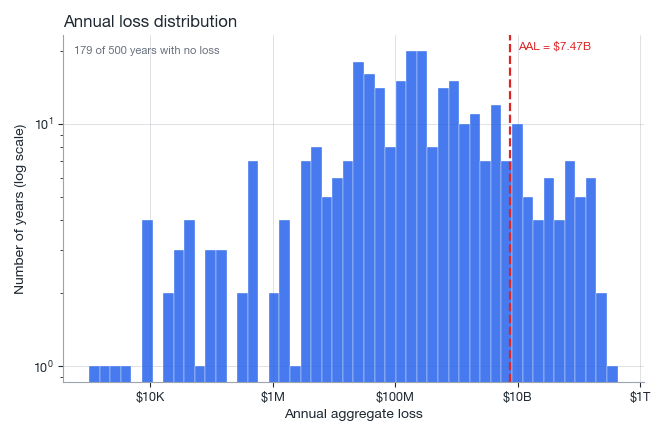

In [6]:
fig, ax = plotting.plot_annual_loss_distribution(results.annual_losses)


## Exceedance probability

`ExceedanceProbability.from_simulation` builds both the aggregate (AEP, total
loss per year) and occurrence (OEP, largest single event per year) exceedance
curves from the simulated years.


In [7]:
from natcat.financial import ExceedanceProbability

ep = ExceedanceProbability.from_simulation(results)


Loss at standard return periods, in millions of dollars:


In [8]:
return_periods = [10, 25, 50, 100, 250]
rp_table = pd.DataFrame(
    {
        "AEP ($M)": np.atleast_1d(ep.loss_at_return_period(return_periods, kind="aep")) / 1e6,
        "OEP ($M)": np.atleast_1d(ep.loss_at_return_period(return_periods, kind="oep")) / 1e6,
    },
    index=pd.Index(return_periods, name="return_period (years)"),
)
rp_table


,AEP ($M),OEP ($M)
return_period (years),,
10,"7,990.66","7,974.85"
25,"57,144.53","56,306.76"
50,"117,408.56","114,621.84"
100,"176,640.92","172,825.02"
250,"253,388.45","249,594.09"


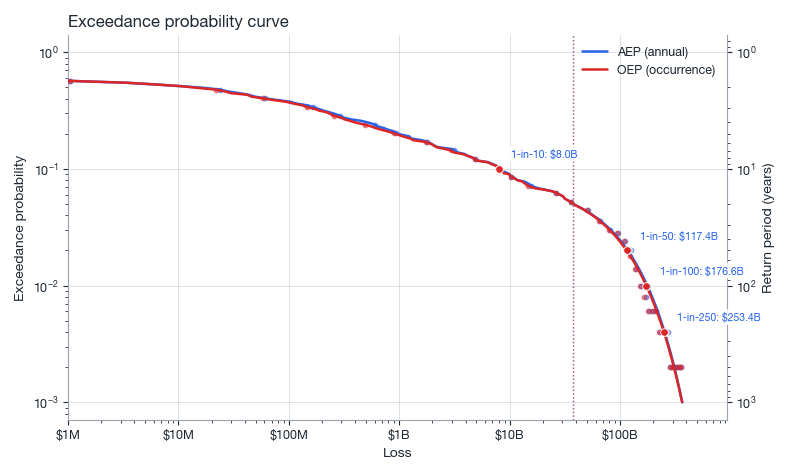

In [9]:
fig, ax = plotting.plot_ep_curve(ep)


## GPD tail fit

Beyond the empirical range, NatCat can fit a Generalized Pareto Distribution
(GPD) to the exceedances above a high threshold. With only 500 simulated
years this can fail for a thin tail — `tail_fit` raises `RuntimeError` when
too few threshold exceedances are available, in which case the curve simply
stays empirical.


In [10]:
for kind in ("aep", "oep"):
    try:
        shape, loc, scale, threshold = ep.tail_fit(kind)
        print(
            f"{kind.upper()} GPD tail: shape={shape:.3f}, loc=${loc:,.0f}, "
            f"scale=${scale:,.0f}, threshold=${threshold:,.0f}"
        )
    except RuntimeError as exc:
        print(f"{kind.upper()}: {exc}")


AEP GPD tail: shape=-0.025, loc=$0, scale=$88,184,291,613, threshold=$37,521,362,452
OEP GPD tail: shape=-0.003, loc=$0, scale=$84,263,772,979, threshold=$37,509,652,377


## Layer pricing

The expected annual loss to a reinsurance layer `limit xs attachment` is the
integral of the occurrence exceedance probability curve between the
attachment point and the top of the layer — this is the standard "integrate
the survival function" identity for the expectation of a capped, non-negative
random variable. We evaluate it numerically with `numpy.trapz` over the OEP
curve.


In [11]:
def expected_layer_loss(ep, attachment, limit, n_points=2000):
    """Expected annual loss to a `limit` xs `attachment` layer.

    Integrates the occurrence exceedance probability curve, i.e.
    E[min(max(loss - attachment, 0), limit)] = integral_{attachment}^{attachment+limit} OEP(x) dx.
    """
    losses = np.linspace(attachment, attachment + limit, n_points)
    exceedance_prob = ep.oep(losses)
    return float(np.trapz(exceedance_prob, losses))


attachment, limit = 50e6, 100e6
layer_loss = expected_layer_loss(ep, attachment, limit)
print(f"Layer: ${limit / 1e6:.0f}M xs ${attachment / 1e6:.0f}M")
print(f"Expected annual loss to layer: ${layer_loss:,.0f}")
print(f"Layer loss cost rate (expected loss / limit): {layer_loss / limit:.2%}")


Layer: $100M xs $50M
Expected annual loss to layer: $37,218,109
Layer loss cost rate (expected loss / limit): 37.22%


## Next steps

- Increase `n_years` in `LossSimulator.run` (1000+) for more stable tail and
  return-period estimates, especially above the 100-year return period.
- Vary `buffer_deg` to see how sensitive results are to which storms are
  considered "close enough" to the portfolio to evaluate.
- Explore alternative vulnerability assumptions (`WindVulnerability(params=...)`)
  or a different exposure footprint to see how portfolio composition changes
  the AAL and the shape of the EP curves.
- Price additional layers by calling `expected_layer_loss` with different
  `attachment`/`limit` pairs, or build a full tower and compare rate-on-line
  across layers.
